In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
val = pd.read_parquet('data/val.parquet')

In [3]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5']

# Isolation Forest


In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# select features
features = x_cols if 'x_cols' in globals() else train.select_dtypes(include=[np.number]).columns.drop('Type', errors='ignore').tolist()

# assume majority class is "normal" / inlier
inlier_label = train['Type'].mode()[0]
X_inlier = train.loc[train['Type'] == 1, features]
#X_inlier2 = train.loc[train['Type'] == 2, features]
#X_inlier = pd.concat([X_inlier1, X_inlier2])

Precision: 0.2630732751327715
Recall:    1.0
F1:        0.4165605912374606
Confusion matrix:
 [[   199 918997]
 [     0 328070]]
F1:        0.4165605912374606
Confusion matrix:
 [[   199 918997]
 [     0 328070]]
ROC AUC (anomaly score): 0.6136160093231683
ROC AUC (anomaly score): 0.6136160093231683


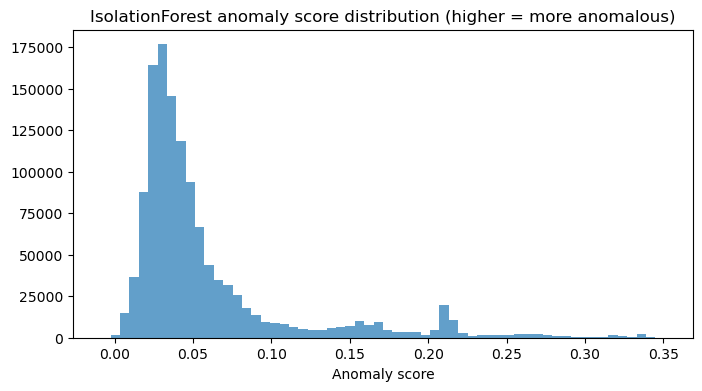

In [ ]:
# estimate contamination (fallback >0)
contamination = max((train['Type'] != inlier_label).mean(), 0.001)

#  {'n_estimators': 400, 'max_samples': 0.7911393175924574, 'contamination': 0.032805025977668774, 'max_features': 0.10554249997403164, 'bootstrap': False}
iso = IsolationForest(n_estimators=400,
                      max_samples=0.7911393175924574,
                      contamination=0.232805025977668774,
                      max_features=0.10554249997403164,
                      bootstrap=False,
                      random_state=42,
                      n_jobs=1,
                      verbose=1) 
#IsolationForest(n_estimators=400, max_samples=0.7911393175924574, contamination=0.032805025977668774, max_features=0.10554249997403164, bootstrap=False, random_state=42, n_jobs=1)
iso.fit(X_inlier)

# predict on test set
X_test = test[features]
y_test = test['Type']
pred = iso.predict(X_test)         # 1 = inlier, -1 = outlier
y_pred_anom = (pred == -1).astype(int)  # 1 = anomaly
y_true_anom = (y_test != inlier_label).astype(int)

# metrics
print("Precision:", precision_score(y_true_anom, y_pred_anom, zero_division=0))
print("Recall:   ", recall_score(y_true_anom, y_pred_anom, zero_division=0))
print("F1:       ", f1_score(y_true_anom, y_pred_anom, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_true_anom, y_pred_anom))

# optional ROC AUC using decision_function (higher => more normal, invert for anomaly)
try:
    scores = -iso.decision_function(X_test)
    print("ROC AUC (anomaly score):", roc_auc_score(y_true_anom, scores))
except Exception:
    pass

# plot score distribution
scores_plot = scores if 'scores' in locals() else -iso.score_samples(X_test)
plt.figure(figsize=(8,4))
plt.hist(scores_plot, bins=60, color='C0', alpha=0.7)
plt.title('IsolationForest anomaly score distribution (higher = more anomalous)')
plt.xlabel('Anomaly score')
plt.show()

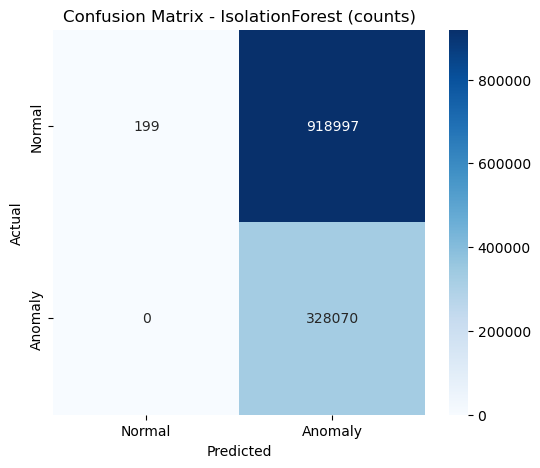

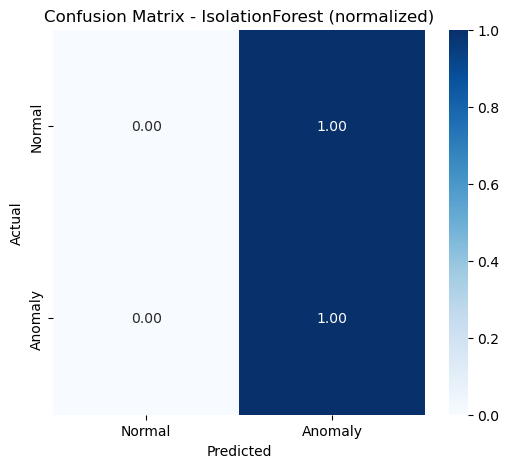

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# recompute confusion matrix (uses y_true_anom, y_pred_anom from previous cell)
cm = confusion_matrix(y_true_anom, y_pred_anom)

# plot absolute counts
plt.figure(figsize=(6,5))
class_labels = ['Normal', 'Anomaly']  # 0 = normal/inlier, 1 = anomaly/outlier
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - IsolationForest (counts)')
plt.show()

# optional: plot normalized confusion matrix (percent)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - IsolationForest (normalized)')
plt.show()

# Autoencoder


Using inlier label = 1 for autoencoder training


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 123)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │         7,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 60)             │         1,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 123)            │         7,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,578 (76.48 KB)

 Trainable params: 19,578 (76.48 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3358 - val_loss: 0.1660 - learning_rate: 0.0010
Epoch 2/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.3358 - val_loss: 0.1660 - learning_rate: 0.0010
Epoch 2/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.1465 - val_loss: 0.1253 - learning_rate: 0.0010
Epoch 3/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.1465 - val_loss: 0.1253 - learning_rate: 0.0010
Epoch 3/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.1169 - val_loss: 0.1269 - learning_rate: 0.0010
Epoch 4/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.1169 - val_loss: 0.1269 - learning_rate: 0.0010
Epoch 4/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.1157 - val_loss: 0.1019 - learning_rate: 0.0010
Epoch 5/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.1157 - val_loss: 0.1019 - learning_rate: 0.0010
Epoch 5/200
4606/4606 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.1003 - val_loss: 0.1029 - lea

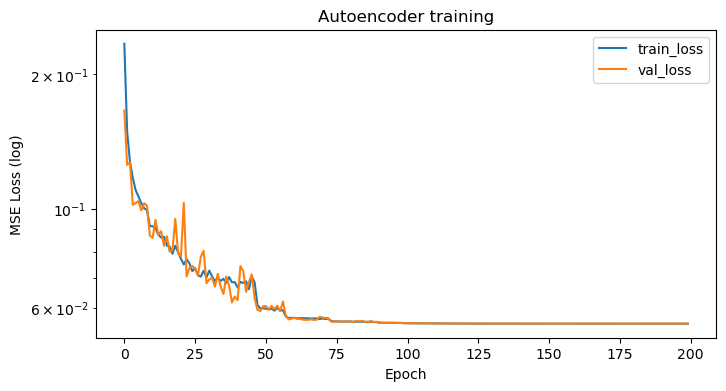

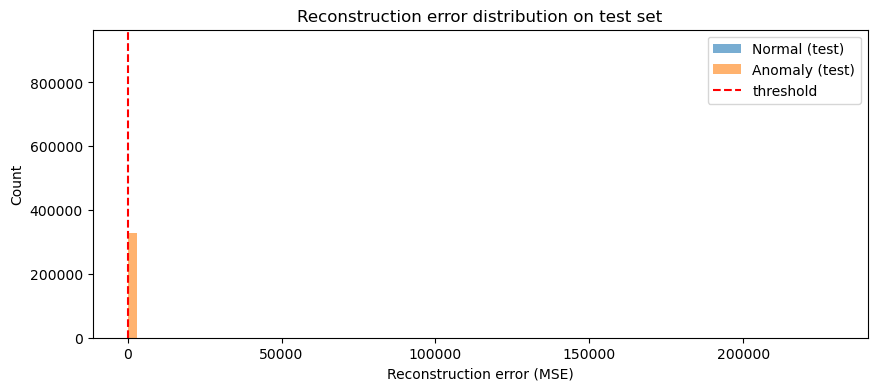

Predicted anomalies on test: 888036 samples


,Attack ID,Avg source IP count,Detect count,Victim IP,Port number,Packet speed,Data speed,Avg packet len,Source IP count,Packet speed_normalized,...,Is_L2TP,Is_GRE,Is_ESP,Is_AH,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,Type
8,702946,1,1,1386,0,58800,32,586,1,0.003641,...,False,False,False,False,-5.461304e+07,-68082.381647,95091.425838,124946.316939,309704.191628,1
9,702946,1,2,1386,33252,68200,37,584,1,0.004420,...,False,False,False,False,-5.397123e+07,-29054.546451,-238898.562896,-192498.446785,387642.168790,1
34,702952,1,1,1386,0,60200,33,588,1,0.003757,...,False,False,False,False,-5.450805e+07,-77618.854488,94187.375016,124786.164143,310367.608041,1
170,702986,1,1,1386,443,67900,37,586,1,0.004395,...,False,False,False,False,-5.398233e+07,-33586.911835,-45676.144752,-10555.520740,341873.981115,1
171,702986,1,2,1386,33252,57500,32,590,1,0.003533,...,False,False,False,False,-5.465463e+07,-13603.418814,-237312.616431,-192128.907956,386664.272813,1
172,702986,1,3,1386,443,53500,29,586,1,0.003201,...,False,False,False,False,-5.494313e+07,-35727.773546,-45738.615615,-10374.573308,342012.008765,1
173,702986,1,4,1386,443,84400,47,586,1,0.005763,...,False,False,False,False,-5.252783e+07,-31269.086252,-45612.365081,-10761.712696,341718.185428,1
185,702996,1,1,1386,0,55200,30,584,1,0.003342,...,False,False,False,False,-5.483865e+07,-84278.685214,93734.742033,124768.890567,310791.228074,1
236,703002,1,1,1386,443,67900,37,586,1,0.004395,...,False,False,False,False,-5.398234e+07,-51270.457265,-47493.618606,-10852.647878,343142.769083,1
244,703008,1,1,1386,0,59100,32,588,1,0.003665,...,False,False,False,False,-5.460345e+07,-79075.103664,94112.640109,124765.409082,310496.015072,1


In [11]:
# Autoencoder for anomaly detection (Keras/TensorFlow)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Select features
features = x_cols if 'x_cols' in globals() else train.select_dtypes(include=[np.number]).columns.drop('Type', errors='ignore').tolist()

# Determine inlier label (majority class)
inlier_label = train['Type'].mode()[0]
print(f"Using inlier label = {inlier_label} for autoencoder training")

# Prepare dataset for autoencoder: only inliers for training
X_inliers = train.loc[train['Type'] == inlier_label, features]

# Split inliers into training and validation (for early stopping and threshold selection)
X_ae_train, X_ae_val = train_test_split(X_inliers, test_size=0.2, random_state=42)

# Fit scaler on inlier training data and transform
scaler_ae = StandardScaler()
X_ae_train_s = scaler_ae.fit_transform(X_ae_train)
X_ae_val_s = scaler_ae.transform(X_ae_val)

# Build a simple dense autoencoder
input_dim = X_ae_train_s.shape[1]
encoding_dim = min(64, max(8, input_dim // 4))  # heuristic

inputs = layers.Input(shape=(input_dim,))
# Encoder
x = layers.Dense(encoding_dim * 2, activation='relu')(inputs)
x = layers.Dense(encoding_dim, activation='relu')(x)
# Bottleneck
encoded = layers.Dense(max(4, encoding_dim // 2), activation='relu')(x)
# Decoder
x = layers.Dense(encoding_dim, activation='relu')(encoded)
x = layers.Dense(encoding_dim * 2, activation='relu')(x)
outputs = layers.Dense(input_dim, activation='linear')(x)

autoencoder = models.Model(inputs, outputs, name='autoencoder')
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

autoencoder.summary()

# Callbacks
es = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8)

# Train
history = autoencoder.fit(
    X_ae_train_s,
    X_ae_train_s,
    epochs=200,
    batch_size=256,
    shuffle=True,
    validation_data=(X_ae_val_s, X_ae_val_s),
    callbacks=[es, reduce_lr],
    verbose=1
)

# Prepare test data
X_test = test[features]
y_test = test['Type']
X_test_s = scaler_ae.transform(X_test)

# Reconstruction errors on validation (to set threshold)
recon_val = np.mean(np.square(autoencoder.predict(X_ae_val_s) - X_ae_val_s), axis=1)
# Choose threshold: e.g., 97.5 percentile of validation reconstruction error
threshold = np.percentile(recon_val, 97.5)
print(f"Selected reconstruction error threshold = {threshold:.6f}")

# Reconstruction errors on test and anomaly predictions
recon_test = np.mean(np.square(autoencoder.predict(X_test_s) - X_test_s), axis=1)
y_pred_anom = (recon_test > threshold).astype(int)
y_true_anom = (y_test != inlier_label).astype(int)

# Metrics
prec = precision_score(y_true_anom, y_pred_anom, zero_division=0)
rec = recall_score(y_true_anom, y_pred_anom, zero_division=0)
f1 = f1_score(y_true_anom, y_pred_anom, zero_division=0)
cm = confusion_matrix(y_true_anom, y_pred_anom)

print(f"Autoencoder anomaly detection:\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1: {f1:.4f}")
print('\nConfusion matrix (rows=true [inlier=0,anom=1], cols=predicted):')
print(cm)
print('\nClassification report:\n', classification_report(y_true_anom, y_pred_anom, zero_division=0))

# Plot training history
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log)')
plt.legend()
plt.title('Autoencoder training')
plt.show()

# Plot reconstruction error distribution with threshold
plt.figure(figsize=(10,4))
plt.hist(recon_test[y_true_anom == 0], bins=80, alpha=0.6, label='Normal (test)')
plt.hist(recon_test[y_true_anom == 1], bins=80, alpha=0.6, label='Anomaly (test)')
plt.axvline(threshold, color='red', linestyle='--', label='threshold')
plt.xlabel('Reconstruction error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.title('Reconstruction error distribution on test set')
plt.show()

# Show some predicted anomalies
anom_idx = np.where(y_pred_anom == 1)[0]
print(f"Predicted anomalies on test: {len(anom_idx)} samples")
if len(anom_idx) > 0:
    display(test.iloc[anom_idx[:10]][features + ['Type']])


# Local Outlier Factor


Using inlier label = 1 for LOF training
Estimated contamination (used for LOF): 0.2607
Estimated contamination (used for LOF): 0.2607
LOF anomaly detection:
Precision: 0.2635
Recall: 0.9970
F1: 0.4168

Confusion matrix (rows=true [inlier=0,anom=1], cols=predicted):
[[  4864 914332]
 [   979 327091]]
LOF anomaly detection:
Precision: 0.2635
Recall: 0.9970
F1: 0.4168

Confusion matrix (rows=true [inlier=0,anom=1], cols=predicted):
[[  4864 914332]
 [   979 327091]]

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.01      0.01    919196
           1       0.26      1.00      0.42    328070

    accuracy                           0.27   1247266
   macro avg       0.55      0.50      0.21   1247266
weighted avg       0.68      0.27      0.12   1247266


Classification report:
               precision    recall  f1-score   support

           0       0.83      0.01      0.01    919196
           1       0.26      1.00      0.42   

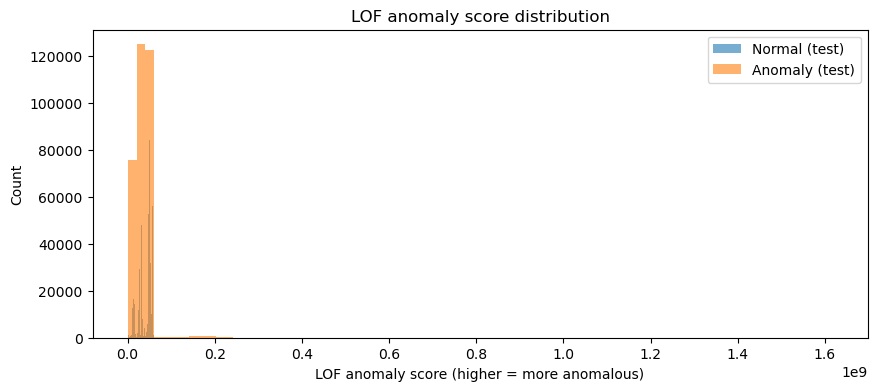

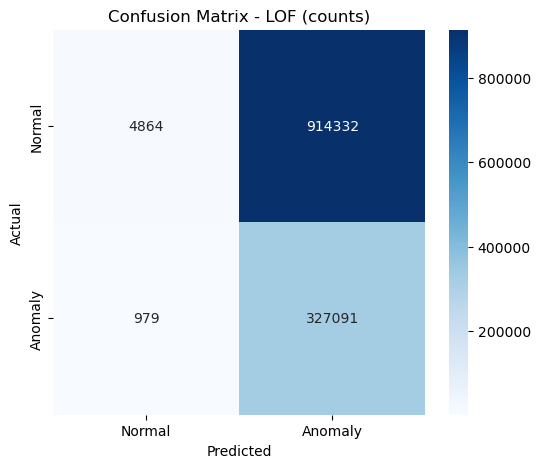

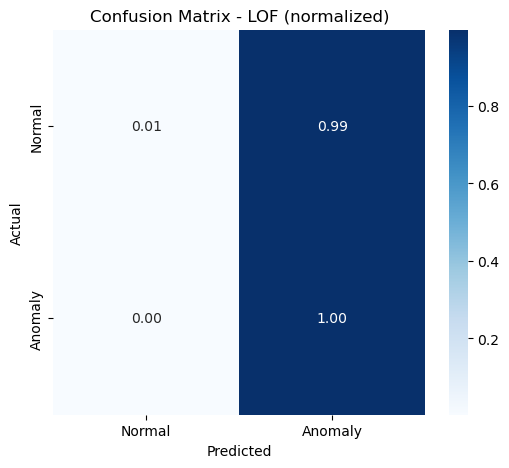

Predicted anomalies: 1241423 samples


,Attack ID,Avg source IP count,Detect count,Victim IP,Port number,Packet speed,Data speed,Avg packet len,Source IP count,Packet speed_normalized,...,Is_L2TP,Is_GRE,Is_ESP,Is_AH,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,Type
0,702942,1,1,60532,0,51800,74,1506,1,0.003060,...,False,False,False,False,-5.266145e+07,-87809.199988,97839.305969,120915.436924,312928.939834,1
1,702942,1,2,60532,0,53700,76,1494,1,0.003218,...,False,False,False,False,-5.241345e+07,-87573.092930,97844.867880,120891.959242,312911.537425,1
2,702942,1,3,60532,0,51100,73,1503,1,0.003002,...,False,False,False,False,-5.276435e+07,-87891.774567,97837.508421,120924.052180,312935.272562,1
3,702943,1,1,67501,0,68000,91,1404,1,0.004403,...,False,False,False,False,-5.030664e+07,-68610.210977,97775.321577,123065.368270,314608.829111,1
4,702944,1,1,60976,0,81600,100,1287,1,0.005531,...,False,False,False,False,-4.833463e+07,-51282.099621,106008.620708,113813.039388,303566.220073,1
5,702944,1,2,60976,64755,58200,71,1281,1,0.003591,...,False,False,False,False,-5.236243e+07,-16160.700718,-229248.686144,-203649.408479,381930.702172,1
6,702945,1,1,67222,0,53900,73,1401,1,0.003234,...,False,False,False,False,-5.255994e+07,-60849.305100,99019.736082,123161.063039,313668.041793,1
9,702946,1,2,1386,33252,68200,37,584,1,0.004420,...,False,False,False,False,-5.397123e+07,-29054.546451,-238898.562896,-192498.446785,387642.168790,1
10,702947,1,1,60976,50104,84000,103,1286,1,0.005730,...,False,False,False,False,-4.784262e+07,-11250.901667,-228895.641013,-203833.839578,381791.161109,1
11,702948,1,1,59468,0,77800,79,1068,1,0.005216,...,False,False,False,False,-5.034843e+07,-54014.777878,110766.548080,106964.862723,296999.255924,1


In [12]:
# Local Outlier Factor (LOF) for anomaly detection
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select features (reuse x_cols if available)
features = x_cols if 'x_cols' in globals() else train.select_dtypes(include=[np.number]).columns.drop('Type', errors='ignore').tolist()

# Determine inlier (majority) label
inlier_label = train['Type'].mode()[0]
print(f"Using inlier label = {inlier_label} for LOF training")

# Training data: use only inliers
X_inliers = train.loc[train['Type'] == inlier_label, features]

# Estimate contamination from training set
estimated_contamination = max((train['Type'] != inlier_label).mean(), 0.001)
print(f"Estimated contamination (used for LOF): {estimated_contamination:.4f}")

# Build LOF as novelty detector (novelty=True) and pipeline with scaler
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=estimated_contamination)
pipe_lof = Pipeline([('scaler', StandardScaler()), ('lof', lof)])

# Fit on inliers only
pipe_lof.fit(X_inliers)

# Predict on test set
X_test = test[features]
y_test = test['Type']

pred = pipe_lof.predict(X_test)  # 1 = inlier, -1 = outlier
y_pred_anom = (pred == -1).astype(int)
y_true_anom = (y_test != inlier_label).astype(int)

# Metrics
prec = precision_score(y_true_anom, y_pred_anom, zero_division=0)
rec = recall_score(y_true_anom, y_pred_anom, zero_division=0)
f1 = f1_score(y_true_anom, y_pred_anom, zero_division=0)
cm = confusion_matrix(y_true_anom, y_pred_anom)

print(f"LOF anomaly detection:\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1: {f1:.4f}")
print('\nConfusion matrix (rows=true [inlier=0,anom=1], cols=predicted):')
print(cm)
print('\nClassification report:\n', classification_report(y_true_anom, y_pred_anom, zero_division=0))

# Decision function / anomaly scores (higher == more anomalous after negation)
try:
    scores = -pipe_lof.named_steps['lof'].decision_function(X_test)
except Exception:
    # fallback to negative score_samples (LOF returns negative for outliers, so invert)
    scores = -pipe_lof.named_steps['lof'].score_samples(X_test)

# Plot score distribution
plt.figure(figsize=(10,4))
plt.hist(scores[y_true_anom == 0], bins=80, alpha=0.6, label='Normal (test)')
plt.hist(scores[y_true_anom == 1], bins=80, alpha=0.6, label='Anomaly (test)')
plt.xlabel('LOF anomaly score (higher = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.title('LOF anomaly score distribution')
plt.show()

# Confusion matrix heatmaps (counts + normalized)
class_labels = ['Normal', 'Anomaly']
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LOF (counts)')
plt.show()

cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LOF (normalized)')
plt.show()

# Show a sample of detected anomalies
anom_idx = np.where(y_pred_anom == 1)[0]
print(f"Predicted anomalies: {len(anom_idx)} samples")
if len(anom_idx) > 0:
    display(test.iloc[anom_idx[:10]][features + ['Type']])


# One-Class SVM


In [ ]:
# One-Class SVM for anomaly detection
from sklearn.svm import OneClassSVM
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select features (reuse x_cols if available)
features = x_cols if 'x_cols' in globals() else train.select_dtypes(include=[np.number]).columns.drop('Type', errors='ignore').tolist()

# Determine inlier (majority) label
inlier_label = train['Type'].mode()[0]
print(f"Using inlier label = {inlier_label} for One-Class SVM training")

# Training data: use only inliers
X_inliers1 = train.loc[train['Type'] == 1, features]
X_inliers2 = train.loc[train['Type'] == 2, features]
X_inliers = pd.concat([X_inliers1, X_inliers2])

# Optional subsample for speed (set to <1.0 to subsample)
sample_frac = 1.0
if sample_frac < 1.0:
    X_inliers_fit = X_inliers.sample(frac=sample_frac, random_state=42)
else:
    X_inliers_fit = X_inliers

# Configure One-Class SVM parameters (tweakable)
nu = 0.02            # upper bound on fraction of training errors (expected outliers)
kernel = 'rbf'       # 'rbf' generally works well; consider 'linear' for very large dims
gamma = 'scale'      # 'scale' or float value

ocsvm = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma, verbose=1)

# Fit on inliers only
ocsvm.fit(X_inliers_fit)

# Predict on test set
X_test = test[features]
y_test = test['Type']

pred = ocsvm.predict(X_test)  # 1 = inlier, -1 = outlier
y_pred_anom = (pred == -1).astype(int)
y_true_anom = (y_test != inlier_label).astype(int)

# Metrics
prec = precision_score(y_true_anom, y_pred_anom, zero_division=0)
rec = recall_score(y_true_anom, y_pred_anom, zero_division=0)
f1 = f1_score(y_true_anom, y_pred_anom, zero_division=0)
cm = confusion_matrix(y_true_anom, y_pred_anom)

print(f"One-Class SVM anomaly detection:\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1: {f1:.4f}")
print('\nConfusion matrix (rows=true [inlier=0,anom=1], cols=predicted):')
print(cm)
print('\nClassification report:\n', classification_report(y_true_anom, y_pred_anom, zero_division=0))

# Decision function / anomaly scores (higher == more anomalous after negation)


Using inlier label = 1 for One-Class SVM training
[LibSVM][LibSVM]One-Class SVM anomaly detection:
Precision: 0.6433
Recall: 0.1569
F1: 0.2522

Confusion matrix (rows=true [inlier=0,anom=1], cols=predicted):
[[890664  28532]
 [276609  51461]]
One-Class SVM anomaly detection:
Precision: 0.6433
Recall: 0.1569
F1: 0.2522

Confusion matrix (rows=true [inlier=0,anom=1], cols=predicted):
[[890664  28532]
 [276609  51461]]

Classification report:
               precision    recall  f1-score   support

           0       0.76      0.97      0.85    919196
           1       0.64      0.16      0.25    328070

    accuracy                           0.76   1247266
   macro avg       0.70      0.56      0.55   1247266
weighted avg       0.73      0.76      0.70   1247266


Classification report:
               precision    recall  f1-score   support

           0       0.76      0.97      0.85    919196
           1       0.64      0.16      0.25    328070

    accuracy                           

AttributeError: 'OneClassSVM' object has no attribute 'named_steps'

In [6]:
try:
    scores = ocsvm.decision_function(X_test)
    auc = roc_auc_score(y_true_anom, scores)
    print(f"ROC AUC (anomaly score): {auc:.4f}")
except Exception:
    # decision_function may be unavailable in some versions; fallback not required
    scores = -ocsvm.named_steps['ocsvm'].score_samples(X_test)

ROC AUC (anomaly score): 0.4780


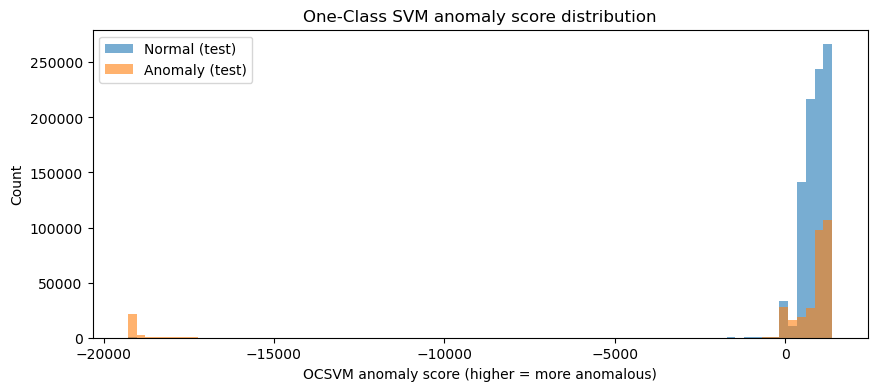

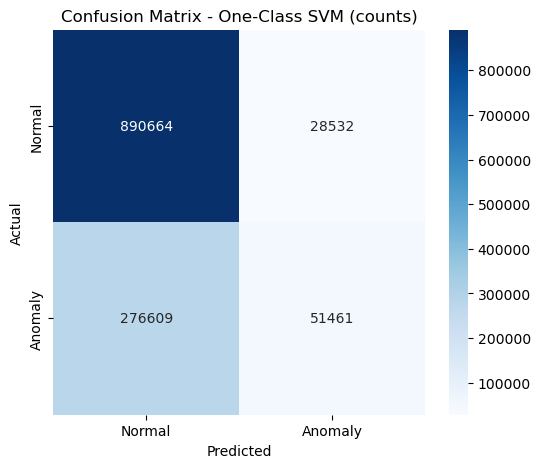

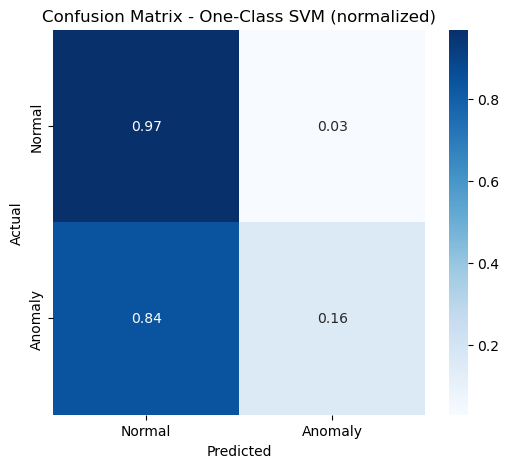

Predicted anomalies: 79993 samples


,Attack ID,Avg source IP count,Detect count,Victim IP,Port number,Packet speed,Data speed,Avg packet len,Source IP count,Packet speed_normalized,...,Is_L2TP,Is_GRE,Is_ESP,Is_AH,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,Type
1533,703119,52,1,18352,0,50300,3,0,52,0.002936,...,False,False,False,False,-5.634375e+07,-90342.774488,94093.204649,124298.618205,312523.750253,2
1581,703146,25,3,47910,443,201800,232,569,24,0.015499,...,False,False,False,False,-9.676905e+06,240483.376775,-18236.959130,-13133.272954,324581.670742,1
1582,703146,25,4,47910,443,263300,298,575,31,0.020599,...,False,False,False,False,2.196891e+07,239091.667114,-18577.975886,-13816.937049,324176.329813,1
1583,703146,25,5,47910,51137,291100,339,586,27,0.022905,...,False,False,False,False,4.218842e+07,257750.137983,-211123.947859,-196051.054898,368796.320172,1
1584,703146,25,6,47910,443,216700,260,595,29,0.016735,...,False,False,False,False,-1.525022e+05,239435.753179,-18360.556586,-13292.909061,324495.883970,1
1585,703146,25,7,47910,443,318800,412,651,45,0.025202,...,False,False,False,False,7.485112e+07,228531.865026,-19422.484108,-14355.214962,323973.170533,1
1587,703146,25,9,47910,443,252500,312,621,26,0.019704,...,False,False,False,False,2.228550e+07,237089.283138,-18647.695867,-13677.890851,324286.783479,1
1589,703148,1,1,57005,0,58900,3,66,1,0.003649,...,False,False,False,False,-5.631795e+07,-78677.261531,96744.489464,123143.565261,314571.662509,1
2360,703189,974,6,26682,443,154600,195,1337,506,0.011585,...,False,False,False,False,-2.634743e+07,486256.174253,5407.977960,-11500.783332,305069.504821,0
2361,703189,974,7,26682,443,200500,253,1347,654,0.015391,...,False,False,False,False,-5.767917e+06,486380.020150,5220.536920,-12020.871726,304746.672165,0


In [7]:
# Plot score distribution
plt.figure(figsize=(10,4))
plt.hist(scores[y_true_anom == 0], bins=80, alpha=0.6, label='Normal (test)')
plt.hist(scores[y_true_anom == 1], bins=80, alpha=0.6, label='Anomaly (test)')
plt.xlabel('OCSVM anomaly score (higher = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.title('One-Class SVM anomaly score distribution')
plt.show()

# Confusion matrix heatmaps (counts + normalized)
class_labels = ['Normal', 'Anomaly']
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - One-Class SVM (counts)')
plt.show()

cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - One-Class SVM (normalized)')
plt.show()

# Show a sample of detected anomalies
anom_idx = np.where(y_pred_anom == 1)[0]
print(f"Predicted anomalies: {len(anom_idx)} samples")
if len(anom_idx) > 0:
    display(test.iloc[anom_idx[:10]][features + ['Type']])